In [ ]:
!pip install --upgrade ipython jupyter
!pip install -U bitsandbytes>=0.46.1
%load_ext autoreload
%autoreload 2

def refresh_repo():
    %cd /kaggle/working
    %rm -rf from-neurons-to-directions
    !git clone https://github.com/jefri021/from-neurons-to-directions.git
    %cd /kaggle/working/from-neurons-to-directions/
    !git pull origin main

refresh_repo()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.14.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currently tak

In [ ]:
import sys
sys.path.insert(0, "/kaggle/working/from-neurons-to-directions/src")

import torch
import matplotlib.pyplot as plt
import gc

from model_utils import (
    load_model_and_tokenizer,
    apply_chat_template,
    get_num_layers,
    generate,
)
from activation_store import ActivationStore
from safety_neurons import (
    collect_generated_span_activations,
    compute_change_scores_rms,
    get_top_safety_neurons,
    compute_causal_effect,
    generate_with_neuron_ablation,
)
from metrics import refusal_rate
from viz import (
    plot_change_score_heatmap,
    plot_neuron_layer_dist,
    plot_causal_effect_bar,
    plot_refusal_rates,
)

print("Imports OK")

Imports OK


In [ ]:
print("Loading base model...")
from transformers import BitsAndBytesConfig

bnb_8bit = BitsAndBytesConfig(load_in_8bit=True)

base_model, base_tokenizer = load_model_and_tokenizer(
    "qwen_base", quantization_config=bnb_8bit, device_map={"": 0}
)
instruct_model, instruct_tokenizer = load_model_and_tokenizer(
    "qwen_instruct", quantization_config=bnb_8bit, device_map={"": 1}
)
n_layers = get_num_layers(base_model)

print(f"\nModel loaded | {n_layers} layers")

# cand_layers = list(range(n_layers // 4, 3 * n_layers // 4))
cand_layers = [16]

print(f"True base_model footprint: {base_model.get_memory_footprint() / 1e9:.2f} GB")
print(f"True instruct_model footprint: {instruct_model.get_memory_footprint() / 1e9:.2f} GB")

print(f"Allocated cuda:0: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"Allocated cuda:1: {torch.cuda.memory_allocated(1) / 1e9:.2f} GB")
print(f"Reserved (what nvidia-smi sees): {torch.cuda.memory_reserved(0) / 1e9:.2f}, {torch.cuda.memory_reserved(1) / 1e9:.2f} GB")
torch.cuda.empty_cache()
print(f"After reclaiming: {torch.cuda.memory_reserved(0) / 1e9:.2f}, {torch.cuda.memory_reserved(1) / 1e9:.2f} GB")

Loading base model...
Loading 'qwen_base' from /kaggle/input/models/qwen-lm/qwen2.5/transformers/7b/1 ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  7.6B parameters | devices: {'cuda:0'}
Loading 'qwen_instruct' from /kaggle/input/models/qwen-lm/qwen2.5/transformers/7b-instruct/1 ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  7.6B parameters | devices: {'cuda:1'}

Model loaded | 28 layers
True base_model footprint: 8.71 GB
True instruct_model footprint: 8.71 GB
Allocated cuda:0: 8.72 GB
Allocated cuda:1: 8.72 GB
Reserved (what nvidia-smi sees): 14.64, 14.62 GB
After reclaiming: 12.07, 12.08 GB


In [ ]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

hf_token = UserSecretsClient().get_secret("HF-READ")

harmful_ds = load_dataset("walledai/AdvBench", token=hf_token)
harmless_ds = load_dataset("tatsu-lab/alpaca", token=hf_token)

harmful = harmful_ds["train"]
harmless = harmless_ds["train"]

harmful_prompts_raw = harmful["prompt"]

# Keep only Alpaca samples with empty input field
harmless_prompts_raw = [
    instruction
    for instruction, inp in zip(harmless["instruction"], harmless["input"])
    if inp.strip() == ""
]

n = min(len(harmful_prompts_raw), len(harmless_prompts_raw))

harmful_prompts_raw = harmful_prompts_raw[:n]
harmless_prompts_raw = harmless_prompts_raw[:n]

print(f"Harmful prompts  : {len(harmful_prompts_raw)}")
print(f"Harmless prompts : {len(harmless_prompts_raw)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/520 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Harmful prompts  : 520
Harmless prompts : 520


In [ ]:
scores = torch.load("/kaggle/working/from-neurons-to-directions/data/change_scores.pt")

## 7. Visualize change scores

Heatmap: rows = layers, columns = top neurons per layer by change score.
Color intensity = how much that neuron changed after alignment.

What to look for:
  - Do changes cluster in specific layers? (localization)
  - Are a few neurons far brighter than the rest? (sparsity)

Saved → /kaggle/working/p2_change_heatmap.png


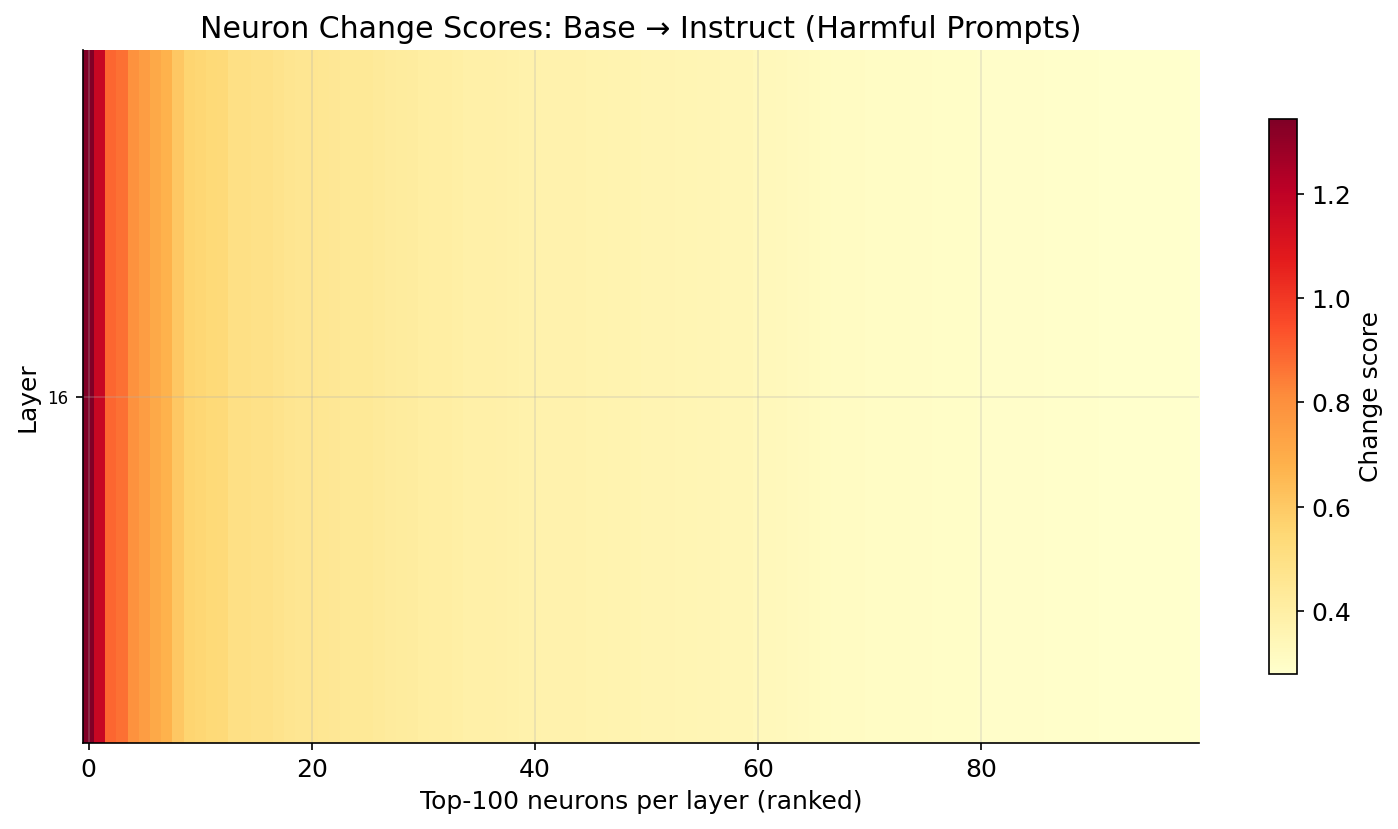

In [ ]:
fig = plot_change_score_heatmap(
    scores=scores,
    top_k_neurons=100,
    title="Neuron Change Scores: Base → Instruct (Harmful Prompts)",
    save_path="/kaggle/working/p2_change_heatmap.png",
)
plt.show()

## 8. Select top safety neurons

Rank all neurons globally by change score and take the top k.
We start with k=500 (~0.1% of all neurons) for efficiency,
then scale up in the causal effect analysis.

In [ ]:
top_neurons = get_top_safety_neurons(scores, k=500)

from model_utils import get_intermediate_size

print(f"Current model intermediate_size : {get_intermediate_size(base_model)}")
print(f"Max neuron index in top_neurons : {max(n for _, n in top_neurons)}")

print(f"\nTop-500 safety neurons selected.")
print(f"Example (layer, neuron_idx): {top_neurons[:5]}")

# Save for later notebooks
torch.save(top_neurons, "/kaggle/working/from-neurons-to-directions/top_neurons.pt")
print("Saved → /kaggle/working/from-neurons-to-directions/top_neurons.pt")

Top-500 safety neurons selected.
  Layer distribution (top 10 layers by count): {16: 500}
Current model intermediate_size : 18944
Max neuron index in top_neurons : 18938

Top-500 safety neurons selected.
Example (layer, neuron_idx): [(16, 18645), (16, 11782), (16, 11920), (16, 17852), (16, 20)]
Saved → /kaggle/working/from-neurons-to-directions/top_neurons.pt


## 9. Visualize neuron layer distribution

How are the top safety neurons distributed across layers?
Paper 2 finds they cluster in mid-to-late layers.
If you see a similar pattern, that's a replication signal.

Saved → /kaggle/working/p2_neuron_dist.png


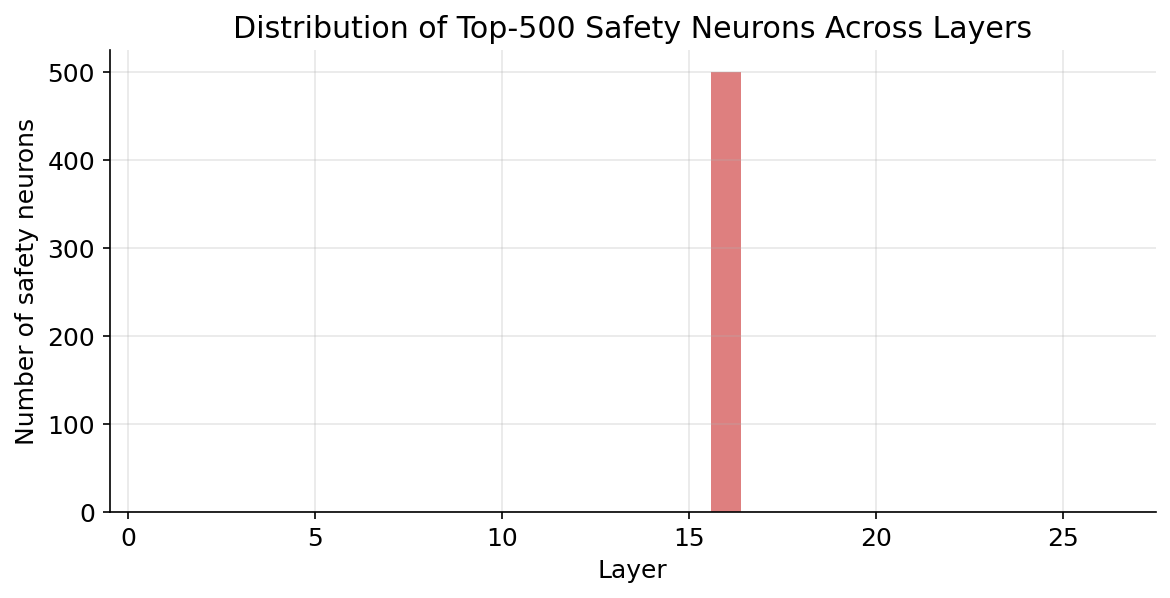

In [ ]:
fig = plot_neuron_layer_dist(
    safety_neurons=top_neurons,
    n_layers=n_layers,
    title="Distribution of Top-500 Safety Neurons Across Layers",
    save_path="/kaggle/working/p2_neuron_dist.png",
)
plt.show()

## 10. Causal effect analysis

The central question: do these neurons actually CAUSE safety behavior?

We measure this by injecting the instruct model's safety neuron
activations into the base model at inference time (dynamic activation
patching) and checking how much of the instruct model's refusal
behavior is recovered.

C = patched_refusal_rate / instruct_refusal_rate

C ≈ 1.0 → these neurons fully explain alignment
C ≈ 0.0 → no causal role

We compute C for increasing k to find the "elbow" — the point where
adding more neurons stops helping. Paper 2 finds the elbow around 5%.

This is slow (~10 min). Use n_eval=10 for a quick check.

In [ ]:
k_values = [50, 100, 250, 500]
causal_effects = {}

for k in k_values:
    print(f"\n--- Evaluating k={k} neurons ---")
    top_k = get_top_safety_neurons(scores, k=k)
    C = compute_causal_effect(
        base_model=base_model,
        instruct_model=instruct_model,
        tokenizer=base_tokenizer,
        harmful_prompts=harmful_prompts_raw,
        safety_neurons=top_k,
        n_eval=10,
    )
    causal_effects[k] = C

torch.save(causal_effects, "/kaggle/working/from-neurons-to-directions/causal_effects.pt")

fig = plot_causal_effect_bar(
    causal_effects=causal_effects,
    title="Causal Effect of Top-k Safety Neurons (Paper 2 Replication)",
    save_path="/kaggle/working/p2_causal_effect.png",
)
plt.show()

## 11. Safety neurons vs random neurons

Paper 2 claims safety neurons are special — not just any neurons
would produce the same causal effect.

We verify this by picking a random set of neurons (same size as our
top-500) and measuring their causal effect. If the random baseline
is near zero and the safety neurons are high, the neurons are special.

In [ ]:
import random
random.seed(42)

intermediate_size = get_intermediate_size(base_model)

# Random neurons: same count as top_neurons, randomly sampled
random_neurons = [
    (random.randint(0, n_layers - 1), random.randint(0, intermediate_size - 1))
    for _ in range(500)
]

print("Computing causal effect for RANDOM neurons (baseline)...")
C_random = compute_causal_effect(
    base_model=base_model,
    instruct_model=instruct_model,
    tokenizer=base_tokenizer,
    harmful_prompts=harmful_prompts_raw,
    safety_neurons=random_neurons,
    n_eval=10,
)

C_safety = causal_effects.get(500, None)
if C_safety is None:
    print("Run section 10 first to get C_safety.")
else:
    print(f"\nCausal Effect — Safety neurons (k=500) : {C_safety:.3f}")
    print(f"Causal Effect — Random  neurons (k=500) : {C_random:.3f}")
    print(f"Safety neurons are {C_safety / max(C_random, 1e-6):.1f}x more effective than random.")

## 12. Verify: neuron ablation suppresses refusal

The mirror of causal effect: if safety neurons cause safety,
then ablating them (zeroing their activations) in the instruct model
should suppress refusal — just like removing the refusal direction did
in notebook 01.

This result is also used in Experiment 2 (notebook 04):
we collect residual stream activations DURING this ablation to see
whether the refusal direction disappears.

Testing safety neuron ablation on instruct model...

Refusal rate — baseline (instruct)   : 100%
Refusal rate — after neuron ablation : 90%
Delta                                : -10%
Saved → /kaggle/working/p2_neuron_ablation.png


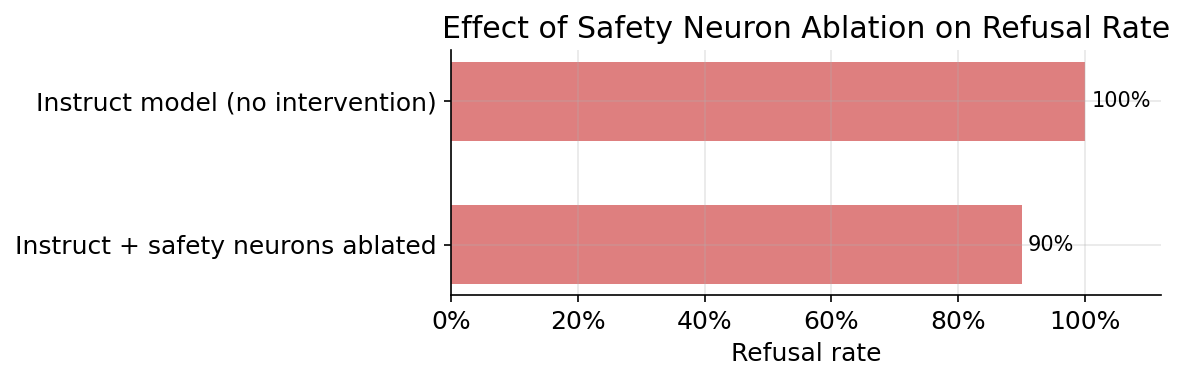

In [ ]:
print("Testing safety neuron ablation on instruct model...")

# Baseline: instruct model with no intervention
baseline_responses = generate(
    instruct_model, instruct_tokenizer,
    [apply_chat_template(p, instruct_tokenizer) for p in harmful_prompts_raw[:20]],
    max_new_tokens=100,
)
baseline_rate = refusal_rate(baseline_responses)

# Ablated: instruct model with safety neurons zeroed out
ablated_responses = generate_with_neuron_ablation(
    model=instruct_model,
    tokenizer=instruct_tokenizer,
    prompts=[apply_chat_template(p, instruct_tokenizer) for p in harmful_prompts_raw[:20]],
    safety_neurons=top_neurons,
    max_new_tokens=100,
)
ablated_rate = refusal_rate(ablated_responses)

print(f"\nRefusal rate — baseline (instruct)   : {baseline_rate:.0%}")
print(f"Refusal rate — after neuron ablation : {ablated_rate:.0%}")
print(f"Delta                                : {ablated_rate - baseline_rate:+.0%}")

# Plot comparison
fig = plot_refusal_rates(
    conditions={
        "Instruct model (no intervention)": baseline_rate,
        "Instruct + safety neurons ablated": ablated_rate,
    },
    title="Effect of Safety Neuron Ablation on Refusal Rate",
    save_path="/kaggle/working/p2_neuron_ablation.png",
)
plt.show()

In [ ]:
print("=" * 55)
print("PAPER 2 REPLICATION SUMMARY")
print("=" * 55)
print(f"Model pair         : Llama-3.1-8B (base) vs Instruct")
print(f"Shared prompts     : 520 harmful, 520 harmless")
print(f"Top safety neurons : {len(top_neurons)}")
print(f"Causal effects     : { {k: f'{v:.2f}' for k, v in causal_effects.items()} }")
print(f"Random baseline    : {C_random:.3f}")
print(f"Baseline refusal   : {baseline_rate:.0%}")
print(f"After ablation     : {ablated_rate:.0%}")
print("=" * 55)
print("\nFiles saved:")
print("  results/change_scores.pt")
print("  results/top_neurons.pt")
print("  results/causal_effects.pt")
print("  results/activations/base/harmful_neurons.pt")
print("  results/activations/base/harmless_neurons.pt")
print("  results/activations/instruct/harmful_neurons.pt")
print("  results/activations/instruct/harmless_neurons.pt")
print("  results/figures/p2_change_heatmap.png")
print("  results/figures/p2_neuron_dist.png")
print("  results/figures/p2_causal_effect.png")
print("  results/figures/p2_neuron_ablation.png")
print("\nNext: run 03_exp1_geometric.ipynb")

PAPER 2 REPLICATION SUMMARY
Model pair         : Llama-3.1-8B (base) vs Instruct
Shared prompts     : 520 harmful, 520 harmless
Top safety neurons : 500
Causal effects     : {50: '0.78', 100: '0.78', 250: '0.78', 500: '0.78'}
Random baseline    : 0.889
Baseline refusal   : 100%
After ablation     : 90%

Files saved:
  results/change_scores.pt
  results/top_neurons.pt
  results/causal_effects.pt
  results/activations/base/harmful_neurons.pt
  results/activations/base/harmless_neurons.pt
  results/activations/instruct/harmful_neurons.pt
  results/activations/instruct/harmless_neurons.pt
  results/figures/p2_change_heatmap.png
  results/figures/p2_neuron_dist.png
  results/figures/p2_causal_effect.png
  results/figures/p2_neuron_ablation.png

Next: run 03_exp1_geometric.ipynb
